# Project Final Report

### Due: 11:59pm on August 9th (with a two hour + one minute grace period) — 50 points  

### No late submissions will be accepted.


Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include code, code screenshots, or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation.
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer in this cell--do not add additional cells" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.




## Submission Checklist

- Final Report Notebook — submitted by team leader  
- **DO NOT SUBMIT Word or PDF files!**



## 1. Executive Summary [4 points]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why.

**1 Answer:**
> - **Background and Problem Framing:** Accurate real-world property valuation is critical for maintaining digital marketplace liquidity, pricing transparency, and consumer trust. The primary objective of this project is to construct a high-performance regression model capable of predicting property assessed tax values (taxvaluedollarcnt) using a comprehensive dataset of structural, physical, and geographic attributes derived from Zillow's 2017 housing records. Real estate data modeling frequently introduces significant challenges, including missing structural values, heavily skewed valuation distributions, overlapping property features, and complex location variables that can destabilize standard machine learning pipelines.
> - **Business Impact and Solution Usage:** From a strategic business perspective, reliable property valuations directly enhance user retention and platform credibility on consumer-facing real estate portals. Operationally, the resulting model integrates seamlessly into automated valuation systems (AVMs) to provide instantaneous home value estimates. Furthermore, the downstream feature importance insights empower the marketing and product teams to execute targeted audience segmentation, build interactive homeownership cost calculators, and optimize high-intent web traffic acquisition by tailoring promotional content to distinct housing market brackets.
> - **Performance Metrics, Findings, and Recommendation:** Model performance is evaluated using Mean Absolute Error (MAE). MAE is measured in dollars, making it intuitively interpretable for both technical data scientists and executive stakeholders. Unlike Mean Squared Error (MSE), which applies a quadratic penalty that can cause rare, multi-million-dollar luxury properties to disproportionately distort error evaluation, MAE treats all dollar errors linearly. Our final model predicts property values within approximately 210,000 dollars on average, given home prices range from just over 1,000 dollars to nearly 49 million dollars. Recommendation: We recommend deploying this model for automated valuation estimates, while continuing to refine predictions for lower and mid-range properties.

## 2. Introduction [3 points]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  

>  - **Context and Background:** This project was developed by an in-house data science team operating within a residential real estate firm. In highly competitive housing markets, relying on manual property appraisals is slow, expensive, and difficult to scale. To maintain market responsiveness, real estate platforms increasingly rely on automated valuation models (AVMs) to estimate property values dynamically.
> - **Problem Statement and Motivation:** The primary problem we are addressing is the inherent pricing variance across diverse geographic and structural housing profiles. Without a rigorous, data-driven predictive pipeline, pricing inaccuracies risk eroding user engagement, misleading home buyers, and damaging platform credibility. The overall motivation for solving this problem is to bridge the gap between raw market data and transparent property valuations, ensuring that our platform remains a trusted, authoritative resource for consumers.
> - **Technical Objectives:** Distinct from our business motivation, the technical objectives and goals of our analysis are centered on model performance and pipeline optimization. Specifically, our goals are to:
>   - Systematically clean and preprocess raw property data to resolve missingness and high-cardinality memory hazards.
>   - Test multiple machine learning architectures—ranging from regularized linear models (Ridge) to non-linear decision trees and advanced gradient boosting ensembles—to determine which modeling paradigm most effectively captures complex property valuation dynamics.
>   - Deliver an interpretable, rigorously validated final model and feature set that minimizes out-of-fold prediction error while generalizing robustly to unseen, held-out test data.

## 3. Data Description [3 points]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  

> - **Source of the Dataset:** The analysis utilizes a subset of the 2017 property transactions dataset provided by Zillow for their Kaggle competition, accessed via the course repository (Zillow Dataset).
> - **Observations and Features:** The raw dataset contained 77,613 property records and 55 features. After removing unusable columns (unique identifiers, features missing more than 70% of their data, and duplicate location codes) and splitting into training and test sets, the dataset stood at 57,089 training observations and 14,273 test observations, with 26 features including the target. A further cleaning step removed individual rows still missing too much data to be reliable, bringing the final modeling dataset to 51,219 training observations and 12,812 test observations. After encoding categorical variables into a machine-readable format, the final feature count used for modeling was 255.
> - **Types of Variables:** The dataset contains a diverse mix of data types, including continuous numerical measurements (e.g., calculatedfinishedsquarefeet, latitude, longitude), discrete counts (e.g., bedroomcnt, bathroomcnt), and categorical or regional identifiers (e.g., fips, regionidcity, buildingqualitytypeid).
> - **Target Variable:** The target variable for this regression task is assessed tax value (taxvaluedollarcnt), which represents the total property tax valuation assigned to each parcel.
> - **Missing Values and Raw Data Issues:** Exploratory data analysis revealed notable real-world data challenges typical of housing datasets. This included extensive missingness across structural attributes (such as air conditioning and pool measurements), severe feature collinearity among correlated room and square footage metrics, and high-cardinality categorical hurdles. Most notably, the raw categorical field propertyzoningdesc contained thousands of unique string values, creating an immediate technical bottleneck where one-hot encoding triggered memory exhaustion errors, necessitating its removal while retaining spatial signal via regional numerical identifiers.

## 4. Methodology (What you did, and why) [20 points]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points.

### 4.1 Analytical Framework

Describe the overall framework you used to develop, compare, and evaluate your models.

This section should explain the structure of your model-development process: what procedures you used, how the stages fit together, and how modeling decisions were made.

> Present the detailed plots, tables, and numerical evidence supporting those decisions later in Section 5.2.

Include:

- how the data were used for training, validation, and final testing,
- the primary evaluation metric you selected, such as MAE or RMSE, and why it was appropriate,
- the procedure you used to compare alternative models, preprocessing choices, and hyperparameter settings, and
- how validation methods, such as cross-validation, validation curves, RandomizedSearch, or Optuna, were incorporated into the model-development process.


**4.1 Answer:**  

> - **Overview of the Analytical Framework:** Our model-development process was structured around an iterative, cross-validation-driven machine learning framework designed to prevent data leakage, evaluate multiple modeling paradigms objectively, and guide decisions from exploratory data analysis to final hyperparameter tuning.
> - **Data Partitioning and Usage:** To ensure unbiased performance estimation, the dataset was strictly partitioned into training and held-out test sets using a fixed random seed (random_state=42) for full reproducibility. The held-out test set remained completely isolated throughout all exploratory data analysis, feature engineering, and hyperparameter tuning stages, being reserved exclusively for the final evaluation of our optimized model.
> - **Primary Evaluation Metric:** We selected Mean Absolute Error (MAE) as our primary optimization and comparison metric across all cross-validation folds. MAE is expressed directly in dollars, making it intuitively interpretable for both technical data scientists and business stakeholders. Unlike Mean Squared Error (MSE), which applies a quadratic penalty that can cause rare, multi-million-dollar luxury properties to disproportionately distort error evaluation, MAE treats all dollar errors linearly. This ensured our optimization efforts focused on delivering stable, reliable predictions across typical residential properties.
> - **Model Comparison and Preprocessing Procedure:** To avoid premature commitment to a single architecture, our workflow systematically compared alternative model classes—spanning regularized linear regression (Ridge), non-linear decision trees, and advanced gradient boosting ensembles (HistGradientBoostingRegressor). Preprocessing choices (such as target log-transformations and feature selection via correlation or permutation importance) were tested iteratively across these models to evaluate whether transformations that benefited linear models also generalized to tree-based architectures.
> - **Validation Methods:** Rigorous 5-fold cross-validation, repeated 5 times (totaling 25 evaluation folds), was integrated into every phase of model development. Rather than relying on a single train-validation split, cross-validation provided stable out-of-fold performance estimates. These estimates guided our feature selection and hyperparameter optimization routines (utilizing search strategies like GridSearchCV), protecting our pipeline against overfitting and ensuring that modeling decisions were backed by robust numerical evidence.

### 4.2 Data Cleaning and Preprocessing

Describe how you cleaned and prepared the raw data for modeling.

Focus on the problems you encountered, the procedures you considered, and the reasoning behind your final preprocessing choices. Detailed plots, tables, and numerical comparisons supporting these decisions should be presented later in Section 5.2.

Include:

* important issues in the raw data, such as missing values, outliers, inconsistencies, or unusable features,
* how you addressed those issues,
* the preprocessing alternatives you considered,
* which procedures you retained for the final analysis and why, and
* which procedures you rejected or changed and why.



**4.2 Answer:**  

> - **Important Issues in the Raw Data:**  Several raw columns had little practical value, for different reasons: some (like parcelid) were unique identifiers with no predictive value, some (like assessmentyear) were constant across every row, and others were missing large portions of their data or duplicated information already captured elsewhere. Beyond individual columns, some rows were missing too much data to be reliable, some numeric-looking columns were actually categorical codes with no real order, and the IQR method flagged a number of unusually high or low property values as potential outliers.
> - **How We Addressed These Issues:** We removed parcelid, assessmentyear, and two redundant census tract columns based on their meaning alone, leaving 51 columns. We then dropped columns missing more than 70% of their data, bringing us to 26 columns, and removed rows still missing more than 20 values. For imputation, we matched the method to each column's actual type: "Unknown" for text categories, 0 for garage features, and mode for the remaining categorical IDs. For encoding, we used ordinal encoding for the one feature with a genuine order (buildingqualitytypeid) and one-hot encoding for the rest. We chose not to remove outliers, treating that as a question to test later against actual model performance rather than deciding upfront.
> - **Preprocessing Alternatives We Considered:** For the missingness cutoff, we started with 50%, chosen because several genuinely important features (heatingorsystemtypeid at 36.13%, unitcnt at 34.67%, and others) fell well below that mark, so this starting point kept them safely in play. Looking closer, we noticed a natural gap in the data: several columns clustered between 77% and 89% missing, then jumped sharply to 90% or higher, with columns beyond that jump mostly ID-like or otherwise uninformative. For sample removal, our first pass dropped rows missing more than 5 of our 26 remaining columns. For imputation, our first attempt was quick and direct, without first checking each column's missingness pattern or true type.
> - **What We Retained and Why:** We set our final missingness cutoff at 70%, right at the natural gap we found, since it separated genuinely unreliable columns from ones still worth keeping; this let us keep garagecarcnt and garagetotalsqft (67.12% missing) since garage information plausibly affects value, treating their missing values as informative (likely meaning no garage). We tightened our row-removal threshold to 20 missing values (roughly 75 to 80% complete) per row. For imputation, we revised our approach to examine each remaining column individually, determining whether it was genuinely numeric or a categorical ID, before choosing a method, since this let us reason clearly about which strategy actually fit which feature.
> - **What We Rejected or Changed and Why:** We moved away from the initial 50% missingness cutoff, since it would have kept columns far too sparse to be reliable. We moved away from the 5-missing-value row threshold, since that level of incompleteness is fairly ordinary in real-world data and would have discarded usable rows unnecessarily. We moved away from our initial direct imputation pass, since it didn't let us reason clearly about which method fit which feature. After further work, we also reconsidered three additional high-cardinality location columns initially kept for their apparent informativeness: once one-hot encoded, they expanded our feature set into the thousands, and test-running Ridge Regression after dropping just one still took over 10 minutes. Since later steps like hyperparameter tuning run models many more times, we dropped all three, bringing our encoded feature count down to a manageable 255 columns while keeping fips and regionidcity for location signal.

### 4.3 Feature Engineering

Describe the feature transformations and new features you considered during model development.

Focus on what you tried, the purpose of each change, and the reasoning behind the features you ultimately retained. Detailed evidence comparing these choices should be presented later in Section 5.2.

Include:

* transformations applied to existing features,
* new features created from the available data,
* the motivation for each transformation or new feature,
* which features or transformations you retained and why, and
* which features or transformations you rejected and why.


**4.3 Answer:**

> - **Transformations and New Features Considered:** We tested three changes directly against our models: removing redundant existing features, log-transforming a skewed existing feature, and scaling existing features. We also considered three new features that never made it into testing: a bathroom-to-bedroom ratio, binning yearbuilt into eras, and a location-based feature grouping properties by latitude and longitude.
> - **Motivation for Each:**  Redundancy removal was motivated by several features being highly correlated with ones we already kept, adding complexity without real value. The log transform was motivated by finishedsquarefeet12 showing a non-linear relationship with the target (r=0.62) and the target itself being heavily right-skewed. Scaling was motivated by our features spanning very different numeric ranges, from lot size in the millions of square feet to bathroom count in single digits, which matters specifically for Ridge Regression's coefficient-penalty mechanism. The bathroom-to-bedroom ratio came from the idea that this proportion might reflect quality or buyer appeal more directly than either count alone; the yearbuilt bins came from noticing older and newer homes span a wide range of values with no simple upward trend; and the location feature came from noticing higher target housing prices concentrated around oceanside areas.
> - **What We Retained and Why:** All three tested changes were evaluated using repeated 5-fold cross-validation (25 total folds), each tested individually while holding other settings constant, so we could isolate each change's own effect. For redundancy, calculatedbathnbr, bathroomcnt, and fullbathcnt were correlated at 0.986 or above, and calculatedfinishedsquarefeet/finishedsquarefeet12 were perfectly correlated; using missing-value rate as a tiebreaker, we kept bathroomcnt and calculatedfinishedsquarefeet and removed the rest, since this had almost no effect on CV MAE across all three models. For the log transform, Ridge Regression's CV MAE improved from 235,926 dollars to 213,939 dollars (about 9%), so we kept it there; for HistGradientBoosting, CV MAE got slightly worse (200,186 to 201,882 dollars), but the gap between training and cross-validation error shrank meaningfully, suggesting better generalization heading into tuning, so we kept it there too. For scaling, we applied it only to Ridge, where the coefficient-penalty mechanism makes scale genuinely relevant.
> - **What We Rejected or Changed and Why:**  We did not apply the log transform to Decision Tree, since it made both CV MAE and its already severe overfitting worse with no offsetting benefit. We did not scale Decision Tree or HistGradientBoosting, since testing scaled versus unscaled versions showed almost no difference for either (Decision Tree: 262,102 unscaled versus 262,525 dollars scaled; HistGradientBoosting: 200,236 unscaled versus 200,120 dollars scaled), confirming both models compare raw feature values against thresholds rather than weighing coefficients. We did not build or test the bathroom-to-bedroom ratio, yearbuilt bins, or location clustering feature, mainly due to time: redundancy removal, log transformation, and scaling were easy to justify directly from existing exploratory charts (boxplots showing near-identical redundant features, histograms showing a clear shift after log-transforming, and feature ranges directly showing the scale differences), while these three new features would have required building an entirely new feature and evaluating the resulting data, meaningfully more work than reading an existing chart.

### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- how validation results were used to compare models and hyperparameters
- how the test set was reserved for the final evaluation of the selected model
- any important trade-offs you considered, such as predictive performance, computational cost, interpretability, or model complexity

**4.4 Answer:**

> - **Models Tried and Why:**  We selected three models representing distinct approaches: Ridge Regression (a regularized linear model), Decision Tree (a single, interpretable tree), and HistGradientBoostingRegressor (a gradient-boosted ensemble). We excluded plain Linear Regression, since it has no real hyperparameter to tune. We also tested Lasso Regression and Random Forest, but abandoned both: Lasso repeatedly failed to converge on our high-dimensional, one-hot encoded data, and Random Forest timed out even at a reduced 3-fold cross-validation, making it impractical for repeated tuning.
> - **How We Evaluated Generalization:** For each model, we compared training error against cross-validation error (with repeated 5-fold cross-validation, 25 total folds) to see how well it would generalize to new data. Decision Tree overfit severely by default, with a training MAE of about 2,108 dollars against a cross-validation MAE of about 262,102 dollars, essentially memorizing the training data rather than learning a pattern that would hold up elsewhere. Ridge showed no meaningful overfitting, with training and cross-validation MAE staying close together. HistGradientBoosting showed mild overfitting, a moderate gap noticeably smaller than Decision Tree's.
> - **How Validation Results Were Used to Compare Models:**  Before tuning, we tested whether narrowing our feature set would help each model. Only HistGradientBoosting showed real improvement from feature selection, with both train and cross-validation MAE decreasing, though its standard deviation increased. Ridge and Decision Tree performed worse across all metrics after feature selection, so we kept feature selection only for HistGradientBoosting (permutation importance, reducing 252 features to 119), while Ridge and Decision Tree retained their full feature sets.
> - **How Validation Results Were Used to Compare Hyperparameters:**  We then tuned hyperparameters using grid search with repeated 5-fold cross-validation, comparing candidate settings by their cross-validation MAE. Decision Tree improved the most, CV MAE dropping by 47,305.94 dollars, since capping max_depth at 13 and requiring min_samples_leaf of 7 both limit how specifically the tree can carve out rules for individual properties, directly addressing its overfitting. HistGradientBoosting improved only marginally (CV MAE down 497.72 dollars), with min_samples_leaf again the most influential parameter, while learning_rate showed no consistent effect, likely because it trades off against the number of boosting iterations. Ridge's CV MAE ended at 211,557.16 dollars, essentially unchanged from its untuned result (211,557.52 dollars), with the best alpha found (0.001) suggesting regularization strength had very little effect on this feature set.
> - **How the Test Set Was Reserved:** The test set was held out completely throughout feature engineering, feature selection, and hyperparameter tuning, used exactly once at the end to evaluate our final selected model.
> - **Trade-offs Considered:** No single model excelled on every measure. HistGradientBoosting had the strongest baseline accuracy (CV MAE 200,236 dollars) but was not the most stable, while Ridge had the best stability (CV standard deviation 2,601 dollars) at the cost of weaker accuracy, and Decision Tree lagged on both before tuning. Computational cost was also a real factor: in baseline testing, Ridge trained in about 11 seconds, Decision Tree in about 60 seconds, and HistGradientBoosting in about 200 seconds, a difference that compounded significantly across repeated cross-validation and grid search, though this cost was worth it for HistGradientBoosting's stronger accuracy. Interpretability told a similar story in reverse: Decision Tree offers the clearest, most traceable decision logic, and Ridge's coefficients directly show each feature's effect, while HistGradientBoosting's ensemble of many trees is the hardest to interpret, a real cost for a model meant to support real-world property valuation decisions.

## 5. Results and Evaluation (What you found, and how well it worked) [16 points]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell.

### 5.1 Model Performance (8 points)

Present and interpret the performance of your selected final model.

Include:

* the final model you selected,
* its performance on the final test set using your primary evaluation metric,
* a practical interpretation of what that error means in the context of the project,
* relevant supporting metrics, such as MAE, RMSE, or $R^2$,
* a comparison with the most important alternative models, and
* a comparison of training, validation, and final test performance to identify possible underfitting, overfitting, or discrepancies between validation and test results.

Focus on the most informative results rather than reporting every metric or model considered.


**5.1 Answer:**  

> - **Final Model Selected:**  Our final model was HistGradientBoostingRegressor, using the feature-engineered, feature-selected, and hyperparameter-tuned pipeline described in Section 4: redundant features removed, target and key features log-transformed, permutation-importance feature selection (keeping 119 of 252 features), and tuned hyperparameters (learning_rate=0.13, max_leaf_nodes=38, min_samples_leaf=20, l2_regularization=2.1). We selected this model because it achieved the lowest cross-validation error among our three candidates.
> - **Test Set Performance:** On the held-out test set, evaluated exactly once after every modeling decision was finalized, our primary evaluation metric, mean absolute error, was 209,569.60 dollars.
> - **Practical Interpretation:** In practical terms, this means our model's property value predictions are typically off by roughly 210,000 dollars. On its own, this is a substantial figure, but it needs to be read against the dataset itself: property values in our dataset range from 1,000 dollars to over 49,000,000 dollars, and the distribution is heavily right-skewed, meaning a relatively small number of very high-value properties pull the average error upward for the dataset as a whole. An error of this size would be a serious problem for predicting the value of a typical mid-range home, but is far more reasonable when the same model also has to account for the occasional multi-million dollar property in the same dataset.
> - **Supporting Metrics:** We used mean absolute error throughout this project as our primary metric, since it treats every dollar of error equally and directly reflects the typical dollar amount our predictions are off by, which is easy to interpret in the context of property valuation.
> - **Comparison with Alternative Models:** Compared to our other two tuned models, HistGradientBoosting's cross-validation MAE (201,239.08 dollars) outperformed both Decision Tree (215,120.72 dollars) and Ridge Regression (211,557.16 dollars). This gap reflects the underlying strengths of each approach: Decision Tree, even after tuning to control its earlier overfitting, is still a single tree and cannot combine multiple weak patterns the way an ensemble can, while Ridge is fundamentally limited by its linear structure, unable to capture the non-linear relationships we observed between features like square footage and property value in our exploratory analysis.
> - **Training, Validation, and Test Comparison:** Training MAE was 185,942 dollars, cross-validation MAE was 201,239.08 dollars, and test MAE was 209,569.60 dollars. The gap between training and cross-validation error reflects the mild overfitting we identified in Section 4.4, which we judged an acceptable trade-off given how much larger this gap was for Decision Tree before tuning. The further gap between cross-validation and test performance is modest, roughly 8,331 dollars, and in the expected direction, since test performance is generally somewhat worse than cross-validation performance on data the model has seen indirectly through repeated validation folds. This suggests our model generalizes reasonably well to genuinely unseen data, without evidence of severe overfitting or a meaningful, concerning discrepancy between our validation process and real-world performance.

### 5.2 Visualizations and Summaries (6 points)

Present at least two clearly labeled visualizations or quantitative summaries that provide meaningful evidence for important modeling decisions or conclusions.

Include plots, tables, or outputs from automated hyperparameter search tools that help demonstrate why particular models, preprocessing choices, features, or hyperparameter settings were retained or rejected.

Insert plots and graphical outputs as clear images directly into the Markdown cell. Tables and concise quantitative summaries may be created using Markdown. Do not include code or code cells. Crop screenshots so that only the relevant material is shown, and ensure that all labels and values are readable.

Each element must be clearly labeled and discussed in the text. Explain what it shows, what conclusion you draw from it, and how it supports a specific modeling decision.

Notes:

* You are not required to include any particular type of plot, such as a validation curve.
* If you used automated methods such as RandomizedSearch or Optuna, include summaries, comparisons, or plots that provide evidence for your model or parameter choices.
* Focus on the most informative evidence rather than including every plot or output produced during Milestone 2.
* The goal is to communicate and justify your decisions, not to reproduce your experimental notebook.


**5.2 Answer:**  

| Figure 1 | Figure 2 | Figure 3 |
|-----------|-----------|-----------|
| 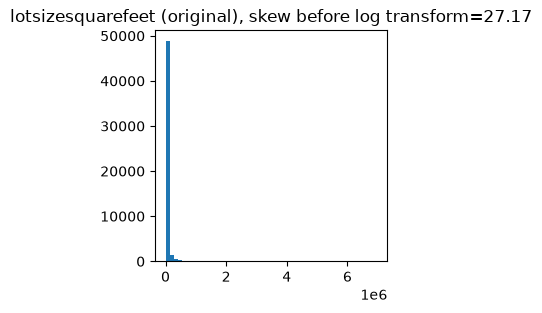 | 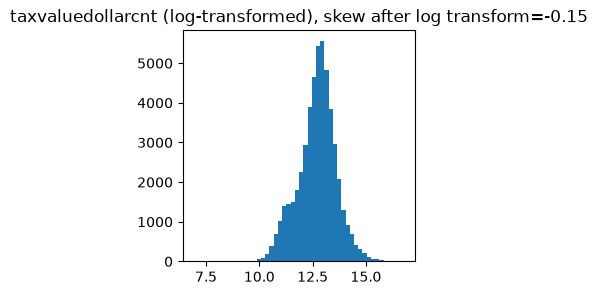 | 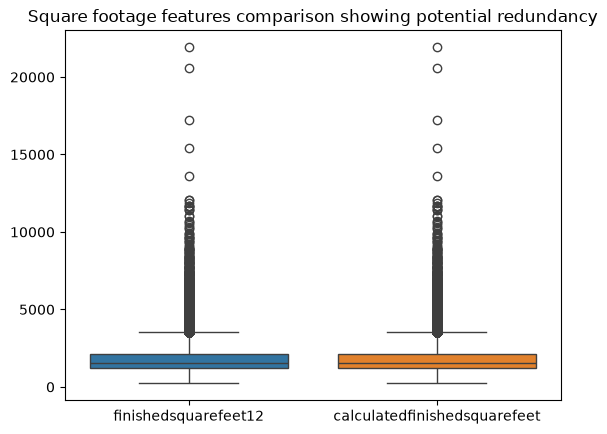|
| **lotsizesquarefeet Before Log Transformation** | **lotsizesquarefeet After Log Transformation** | **Square Footage Redundancy** |

> * Prior to model tuning, we first explored the data in our Zillow dataset and found multiple features that needed to be dropped or undergo a log transformation.
> * In Figure 1, it shows an example of one of the features that needed a log transformation. Before undergoing the log transformation, the feature _lotsizesquarefeet_ exhibited heavy skewness that could have distorted our model's predictions. In Figure 2, however, it shows that after undergoing the log transformation, the feature _lotsizesquarefeet_ appeared more bell-shaped and was better suited for model predictions because the heavy skewness had been reduced.
> * Moreover, Figure 3 shows an example of the distributions of two of our Zillow features, _finishedsquarefeet12_ and _calculatedfinishedsquarefeet_. As shown by the side-by-side boxplots, these distributions were nearly identical and suggested that the data was redundant. Therefore, we dropped _finishedsquarefeet12_ to reduce computational costs because the feature was unnecessary when _calculatedfinishedsquarefeet_ already existed in the dataset.


| Figure 4 | Figure 5 |
|-----------|-----------|
| 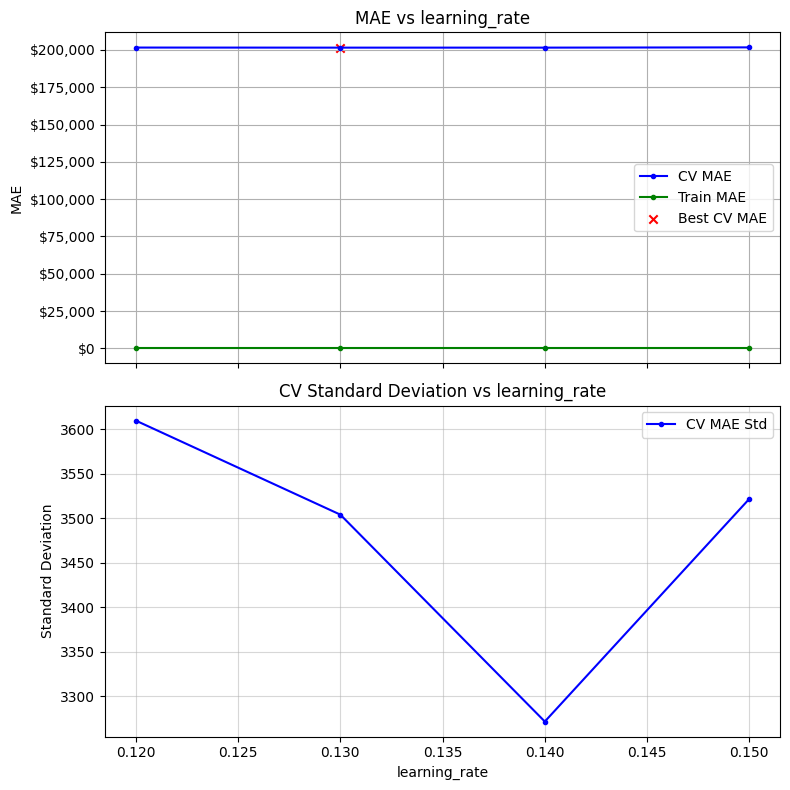 | 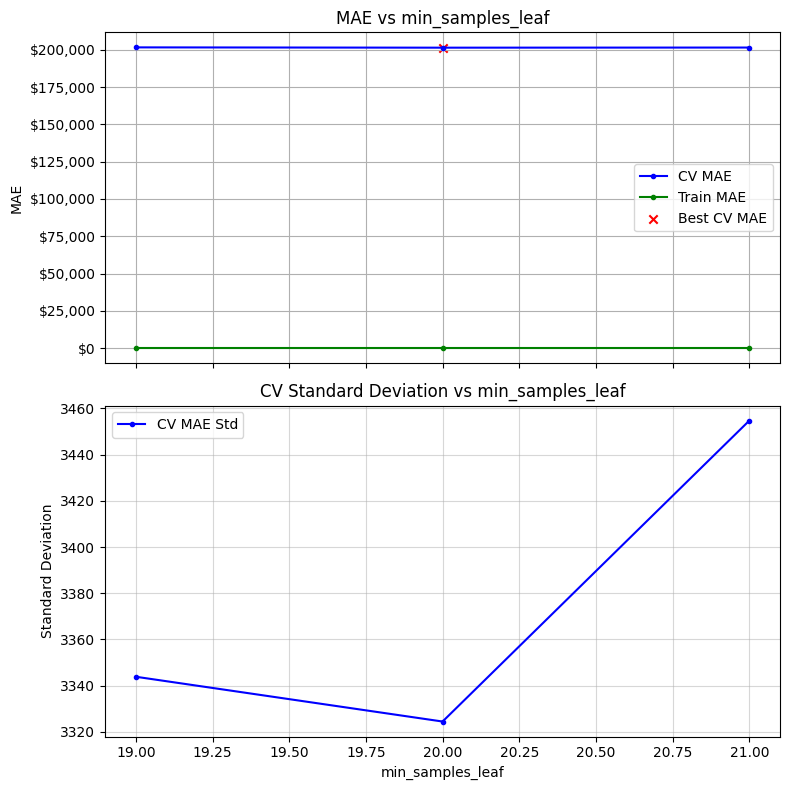 |
| **Learning Rate Hyperparameter Tuning** | **Min Samples Leaf Hyperparameter Tuning** |

> - During our hyperparameter tuning for our best model, HistGradientBoosting, where we wanted to find the best range of values to help train our model, we used line plots to show which parameter values resulted in the best cross-validation MAE and how changing each parameter affected the cross-validation standard deviation, as these were the two metrics we used to determine which model performed best among our three models.
> - In Figure 4, we tested learning rate values of 0.12, 0.13, 0.14, and 0.15 and found that a learning rate of 0.13 resulted in the lowest cross-validation MAE, which can be seen by the red X on the graph. Additionally, the lower graph in Figure 4 shows that the cross-validation standard deviation at the best MAE learning rate was approximately 3,500. Looking at these graphs together also shows that the best MAE may not always result in the lowest standard deviation, as a learning rate of 0.14 had the lowest standard deviation but not the lowest MAE. This demonstrates a tradeoff we encountered during hyperparameter tuning, but we prioritized MAE because it was our primary evaluation metric that measures the lowest error.
> - Similarly, in Figure 5, we tested min_samples_leaf values of 19, 20, and 21 and found that a value of 20 performed the best. In this case, however, we found that 20 not only had the lowest cross-validation MAE but also the lowest cross-validation standard deviation. Unlike the results in Figure 4, there was no tradeoff between these two metrics, making 20 the clear choice for this hyperparameter.
> - By graphing how parameter tuning affected our cross-validation MAE and standard deviation, we were then able to use this knowledge to determine the best parameter values for our HistGradientBoosting model when predicting our target values. Having these optimally tested parameters allows for better predictions and helps reduce the amount of error in our model.

### 5.3 Model Limitations (2 points)

Discuss the most important limitations or weaknesses of your final model.

Base your discussion on the results and analyses completed in Milestone 2. You are not required to conduct new modeling experiments for this section, although you may include an additional numerical summary or visualization if it helps clarify your conclusions.

Include, as appropriate:

- evidence of underfitting, overfitting, instability, or differences among - training, validation, and test performance,
- types of observations or properties that may be especially difficult to predict,
- plausible explanations for the model’s limitations, and
- one or more potential changes that might improve future performance.

Focus on interpreting the model’s limitations rather than merely restating its performance metrics.

**5.3 Answer:**  

> - **Model Performance Recap:**  As mentioned previously, our final model was our HistGradientBoosting model. This model performed with a mean cross-validation MAE of 201,239.08 dollars, a cross-validation standard deviation of 3,365.49 dollars, and a test MAE of 209,569.60 dollars.
> - **Observed Limitation:**  Although the results were similar between our cross-validation MAE and test MAE, both values are still relatively high, suggesting that the model was not able to fully capture all of the patterns in the data.
> - **Potential Improvement — Feature Engineering:** We believe these high MAE values may be due to outliers in the data, such as very expensive houses. However, without further model improvements, we cannot know for sure. Therefore, one change we believe could improve the model is additional feature engineering. Currently, we only performed log transformations to help reduce skewness, but we believe that creating new features, such as ratios between existing features, could help the model capture more meaningful patterns and improve its predictions. For example, we could create a ratio feature of bathrooms to bedrooms, which could possibly show that higher ratios imply more expensive homes and convey patterns better.
> - **Possible Explanation — Outlier Properties:** We theorize the model had more difficulty predicting very expensive houses because these properties are less common in the dataset and may not follow the same pricing patterns as more typical homes. Due to this, these observations can contribute to larger prediction errors.
> - **Potential Improvement — Segmented Modeling:** Additionally, another possible solution for our high MAE is to split the data and train separate models based on property values. For example, we could have one model for more expensive homes and another for less expensive homes. By splitting the data, we believe each model could capture patterns within its price range more effectively. However, this approach could also heavily skew the results if there is not enough data in each group, so we would need to be careful when deciding whether to use this method.

## 6. Conclusion [4 points]

Summarize the main findings and implications of your analysis. This section should not simply repeat the Executive Summary. It is written for a technical audience that has read the full report and should synthesize the evidence, limitations, and practical significance of your work.

Include all of the following:

* clearly state your main findings and explain how they address the original project objectives,
* highlight the business or practical implications of those findings,
* discuss the limitations and constraints of your analysis clearly and transparently,
* suggest potential improvements or directions for future work, and
* conclude with a final recommendation that addresses the original business objective.


**6.1 Answer:**  

> - **Main Findings:** Throughout our model testing, our key objective was to accurately predict real-world property valuations using our Zillow data. To achieve this goal, we evaluated three models: Ridge Regression, HistGradientBoosting, and Decision Tree. Through feature engineering, feature selection, and hyperparameter tuning, we found that HistGradientBoosting consistently performed the best, making it our final model for predicting property values on the testing data. By comparing different models and optimization techniques, we were able to identify the combination that produced the most accurate predictions: a HistGradientBoosting model that used log transformation, feature selection, and hyperparameter tuning.

> - **Business or practical implications:** These improvements help create more reliable property valuations, which can enhance platform credibility for companies like Zillow that rely on accurate housing price predictions to build user trust. More accurate home value estimates help buyers and sellers make more informed decisions and give companies an advantage in the real estate market.

> - **Limitation and constraints:** A key limitation we encountered during our modeling and prediction process was that the MAE was consistently high at a little over $200,000. This suggests that our model is still having difficulty capturing the patterns in the data and is possibly being thrown off by outliers. Despite using feature engineering, feature selection, and hyperparameter tuning, none of our current methods was able to significantly improve the MAE.

> - **Potential Improvements:** Some improvements we believe we can make to help improve our final model include additional feature engineering. As of right now, our model has only gone through log transformation. However, we believe creating additional features, such as ratios between existing features, could help the model capture patterns more effectively. Additionally, we believe training separate models based on different types or price ranges of homes could further improve the model's ability to capture patterns and, in turn, lower the MAE.

> - **Conclusion:** Overall, based on our results, we recommend using the tuned HistGradientBoosting model for predicting Zillow property values, as it consistently outperformed Ridge Regression and Decision Tree throughout our testing. Although the model still has room for improvement due to its relatively high MAE, it provided the best combination of predictive accuracy and generalization. Future work should focus on additional feature engineering and exploring separate models for different price ranges to further improve prediction accuracy.
